In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-05-12
Revised on 2026-04-01

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Time Series SARIMAX Vignette
=============================

Description:
    Comprehensive time series vignette covering synthetic data generation,
    decomposition, and SARIMAX modeling. Topics include:
      - Synthetic seasonal, trend, white noise, and random walk components
      - ACF and PACF analysis (statsmodels)
      - Histogram and Q-Q plot diagnostics (scipy)
      - Seasonal decomposition (statsmodels.tsa.seasonal)
      - Augmented Dickey-Fuller stationarity test (adfuller)
      - SARIMAX model fitting with order (p,d,q)(P,D,Q,M)
      - Auto ARIMA via pmdarima (pm.auto_arima)
      - Holt-Winters ExponentialSmoothing (statsmodels)
      - Forecasting and prediction intervals
    Based on Harvard CSCI E-83 Data Modeling course by Prof. Steven F. Elston,
    Chapter 34. Examples replicated and adapted for educational purposes.

Libraries:
    pandas, numpy, scipy, sklearn, statsmodels, pmdarima, matplotlib

References:
    - Prof. Steven F. Elston, Harvard CSCI E-83:
      https://github.com/StephenElston/CSCI-E-83/blob/master/Notebooks/
      32_Chapter32_IntroToTimeSeries.ipynb
    - Pandas time series:
      https://pandas.pydata.org/pandas-docs/stable/timeseries.html
    - ARIMA tutorial (SciPy 2011):
      https://conference.scipy.org/scipy2011/slides/mckinney_time_series.pdf
    - SARIMAX (statsmodels):
      https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html
    - pmdarima user guide: https://alkaline-ml.com/pmdarima/

Revision History:
    2023-05-12  Original development
                - Synthetic time series: seasonal, trend, white noise, random walk
                - ACF/PACF, hist, Q-Q diagnostics
                - Seasonal decomposition, ADF test
                - SARIMAX fitting, auto_arima, forecasting

    2026-04-01  Sabbatical portfolio refresh
                - Added Cell [1] standard docstring
                - Updated kernel metadata to Python 3.14.3
                - Verified all APIs: statsmodels, pmdarima, scipy, sklearn
                - No deprecated APIs found; code is clean
"""

'\nCreated on 2023-05-12\nRevised on 2026-04-01\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nTime Series SARIMAX Vignette\n=============================\n\nDescription:\n    Comprehensive time series vignette covering synthetic data generation,\n    decomposition, and SARIMAX modeling. Topics include:\n      - Synthetic seasonal, trend, white noise, and random walk components\n      - ACF and PACF analysis (statsmodels)\n      - Histogram and Q-Q plot diagnostics (scipy)\n      - Seasonal decomposition (statsmodels.tsa.seasonal)\n      - Augmented Dickey-Fuller stationarity test (adfuller)\n      - SARIMAX model fitting with order (p,d,q)(P,D,Q,M)\n      - Auto ARIMA via pmdarima (pm.auto_arima)\n      - Holt-Winters ExponentialSmoothing (statsmodels)\n      - Forecasting and predic

# Time Series Vignette

May 12, 2023

@author: Oscar A. Trevizo

Material based on Harvard Data Modeling class conducted by Dr. Steven F. Elston. See references at the bottom of this notebook to find links and additional references.

# Load the libraries

In [2]:
from math import sin
import pandas as pd
import numpy as np
import numpy.random as nr
from math import pi
from scipy.stats import zscore
import sklearn.linear_model as lm
import statsmodels.tsa.seasonal as sts
import scipy.stats as ss
import statsmodels.api as sm
import statsmodels.tsa.arima_process as arima
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing
import pmdarima as pm
import statsmodels.graphics.tsaplots as splt
import matplotlib.pyplot as plt

%matplotlib inline

# Functions

In [3]:
# Plot a time series
# Based on funciton by Dr. Steven F. Elston. 
#  https://github.com/StephenElston/CSCI-E-83/blob/master/Notebooks/32_Chapter32_IntroToTimeSeries.ipynb 
def ts_plot(ts, label = '', units = 'Value', fig_height = 4, fig_length = 9):
    _,ax = plt.subplots(figsize=(fig_length, fig_height))
    ts.plot(ax=ax)
    ax.set_title('Time series plot of ' + label)
    ax.set_ylabel(units)
    ax.set_xlabel('Date')

# Plot the distribution: histogram and Q-Q plots
# Source https://github.com/StephenElston/CSCI-E-83/blob/master/Notebooks/32_Chapter32_IntroToTimeSeries.ipynb
def hist_qq_plots(ts, label = '', units = 'Value', bins = 40, fig_height = 4, fig_length = 9):
    _,ax = plt.subplots(1,2,figsize=(fig_length, fig_height))
    ## Plot the histogram with labels
    ts.hist(ax = ax[0], bins = bins, alpha = 0.5);
    ax[0].set_xlabel(units);
    ax[0].set_ylabel('Frequency');
    ax[0].set_title('Histogram of ' + label);
    ## Plot the q-q plot on the other axes
    ss.probplot(ts, plot = ax[1]);

# Plot Autocorrelation and Partial Autocorreleation
# Source https://github.com/StephenElston/CSCI-E-83/blob/master/Notebooks/32_Chapter32_IntroToTimeSeries.ipynb
def acf_pacf_plots(ts, fig_height = 8, fig_length = 8):
    _,ax = plt.subplots(2,1, figsize=(fig_length, fig_height))
    _=splt.plot_acf(ts, lags = 40, ax=ax[0]);
    _=splt.plot_pacf(ts, lags = 40, method='yw', ax=ax[1]);

# Decomposition of time series
# Source https://github.com/StephenElston/CSCI-E-83/blob/master/Notebooks/32_Chapter32_IntroToTimeSeries.ipynb
def decomp_ts(ts, freq = 'M', model = 'additive'):
    res = sts.seasonal_decompose(ts, model = model) 
    res.plot()
    return(pd.DataFrame({'resid': res.resid, 
                         'trend': res.trend, 
                         'seasonal': res.seasonal},
                       index = ts.index) )


# Create seasonal time series

In [4]:
# Define the date range
start = '1-1-2019'
end = '12-31-2022'
freq = 'W'
dates = pd.date_range(start = start, end = end, freq = freq)


In [5]:
s = pd.Series([2*sin(x*pi/7) for x in range(len(dates))])

# A time series needs a time index.
s.index = pd.date_range(start = start, end = end, freq = 'W')
s.head()

2019-01-06    0.000000
2019-01-13    0.867767
2019-01-20    1.563663
2019-01-27    1.949856
2019-02-03    1.949856
Freq: W-SUN, dtype: float64

In [6]:
s.describe()

count    2.080000e+02
mean     1.168957e-02
std      1.418943e+00
min     -1.949856e+00
25%     -1.563663e+00
50%     -1.224647e-15
75%      1.563663e+00
max      1.949856e+00
dtype: float64

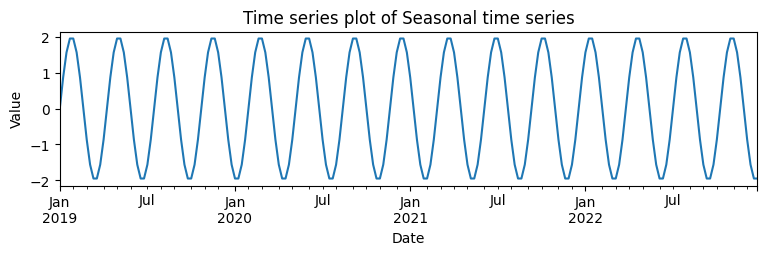

In [7]:
ts_plot(s, label = 'Seasonal time series', units = 'Value', fig_height = 2, fig_length = 9)

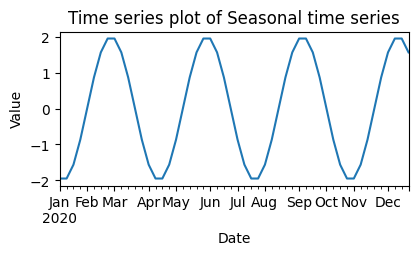

In [8]:
# Plot a subset of the series
ts_plot(s['1/1/2020':'12/31/2020'], label = 'Seasonal time series', units = 'Value', 
        fig_height = 2, fig_length = 4.5)

# White noise

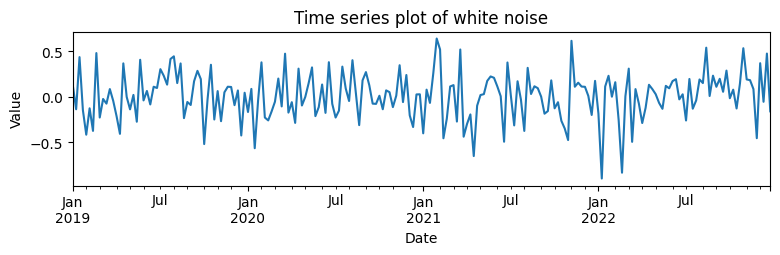

In [9]:
# Create a white noise time series
nr.seed(12321)
white = pd.Series(nr.normal(loc = 0, scale = 0.25, size = len(dates)),
                 index = pd.date_range(start = start, end = end, freq = freq))
ts_plot(white, 'white noise', fig_height = 2, fig_length = 9)

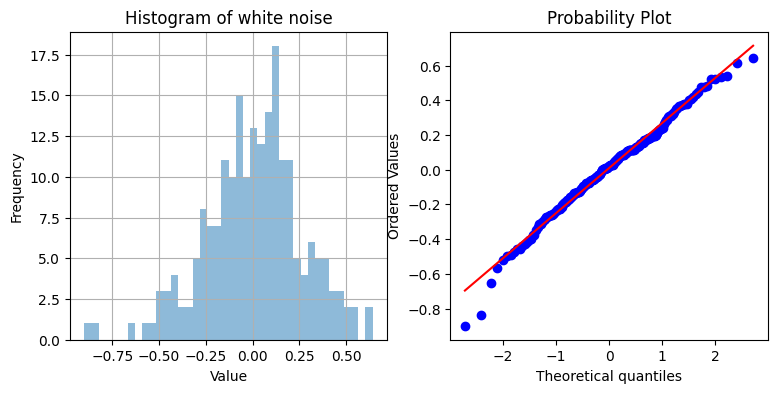

In [10]:
hist_qq_plots(white, 'white noise')    

## ACF and PACF for white noise

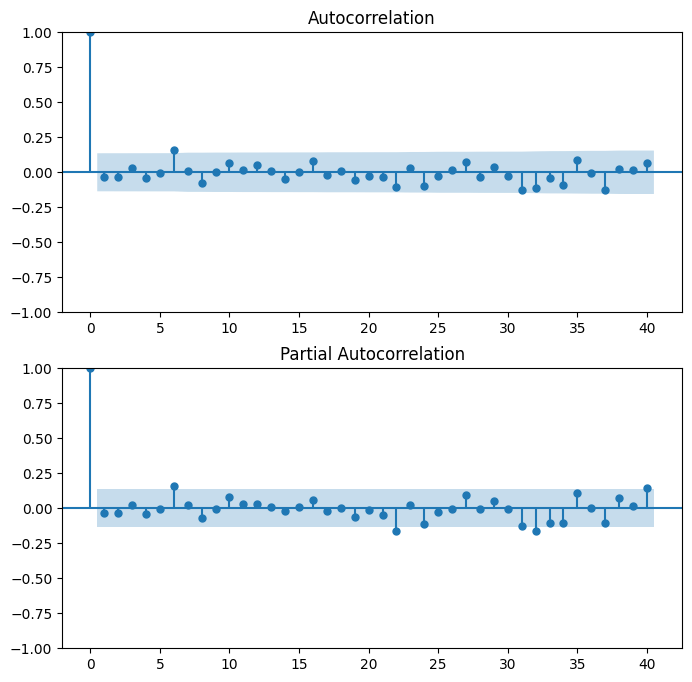

In [11]:
acf_pacf_plots(white)

# Add white noise to the seasonal time series wave

Reduce the white nose sd to have better proportions relative to the seasonal data.

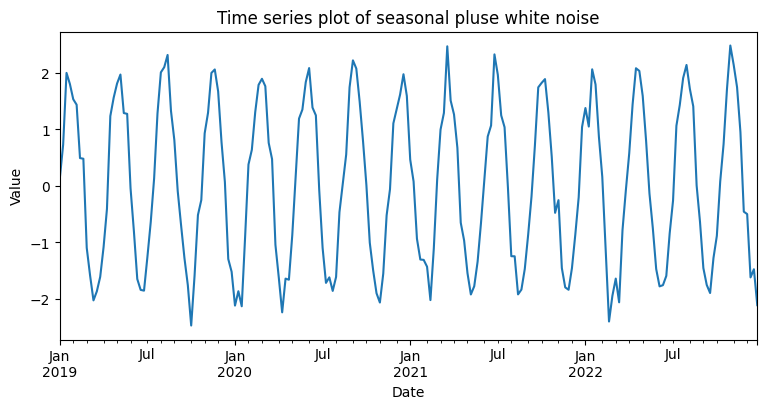

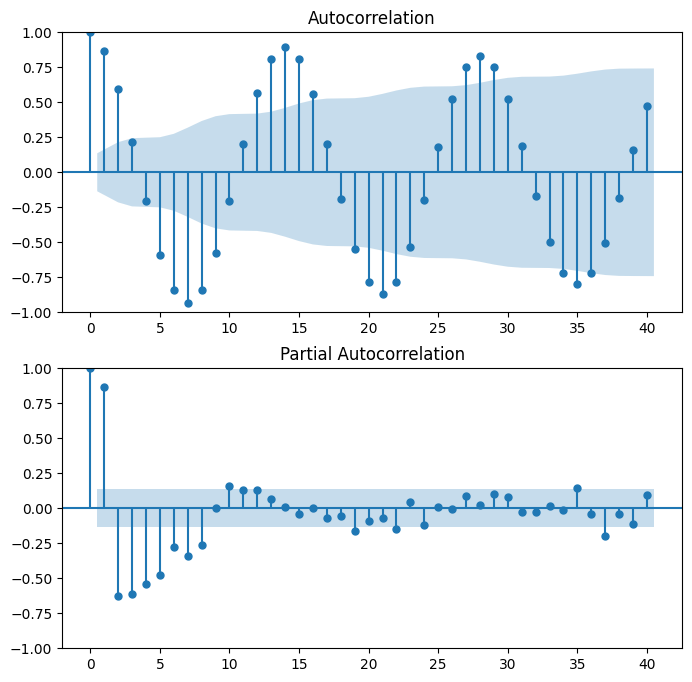

In [12]:
ts = s + white
ts_plot(ts, 'seasonal pluse white noise')
acf_pacf_plots(ts)


# Random Walk

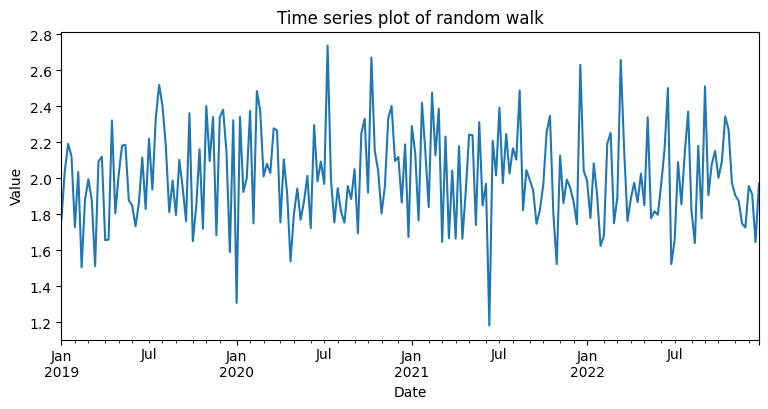

In [13]:
# It really is a white noise with a specific sd and mean
mean = 2
sd = 0.25
walk = pd.Series(nr.normal(loc = mean, scale = sd, size = len(dates)), index = dates)
ts_plot(walk, 'random walk')

## Hist, Q-Q, ACF and PACF for random walk

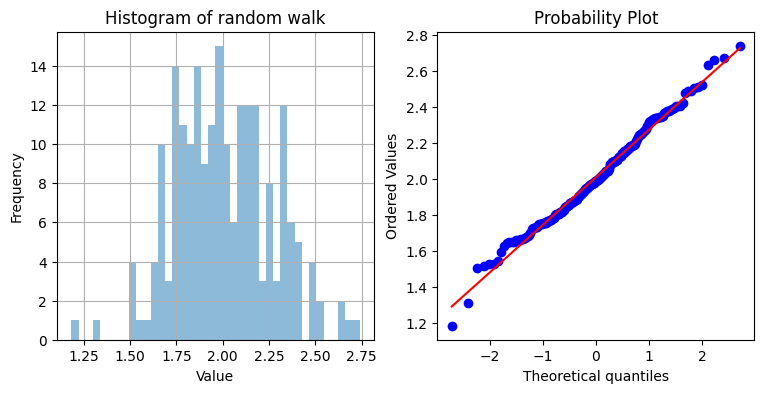

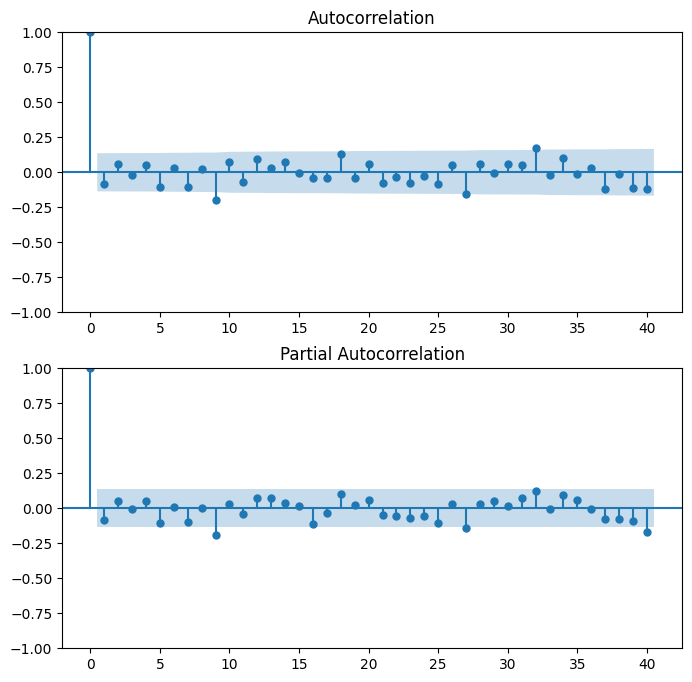

In [14]:
hist_qq_plots(walk, 'random walk')
acf_pacf_plots(walk)

# Trend plus white noise


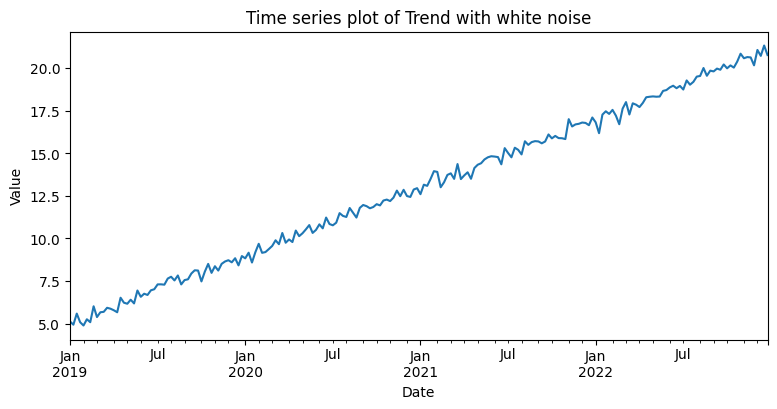

In [15]:
slope = 4/52
trend = pd.Series([5+slope*x for x in range(len(dates))], index = dates)
ts_plot(trend + white, 'Trend with white noise')

## Hist, Q-Q, ACF and PACF for trend + white noise

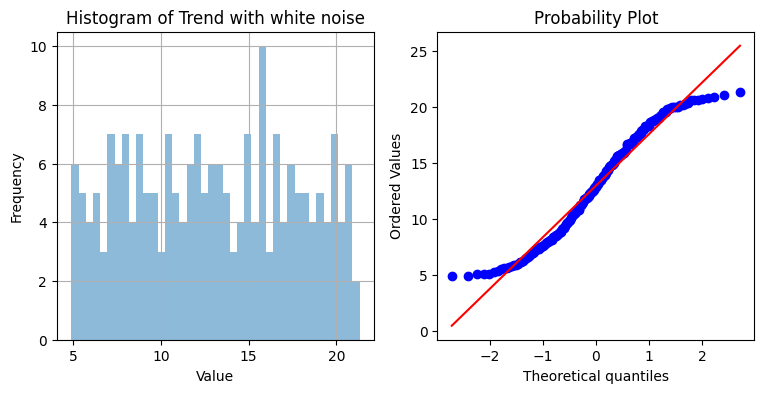

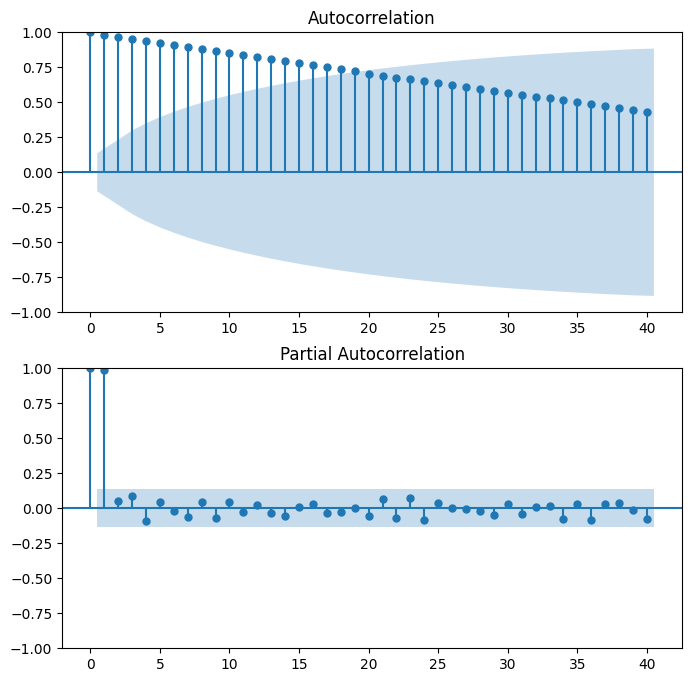

In [16]:
hist_qq_plots(trend + white, 'Trend with white noise')
acf_pacf_plots(trend + white)

# Time Series with a season, trend, white noise components


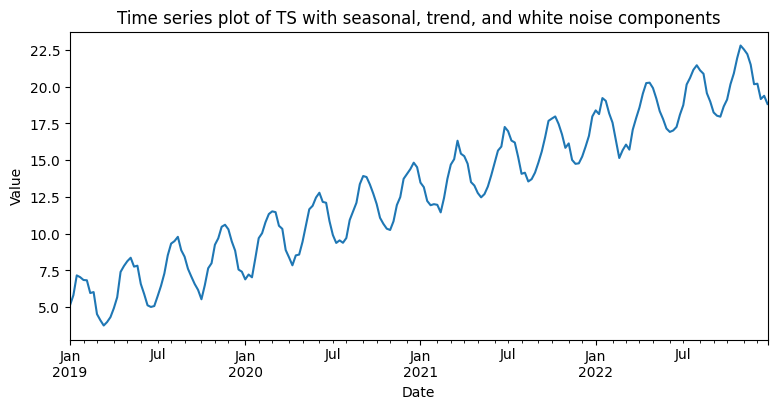

In [17]:
# Here ts already has a seasonal and a white noise compnent from above
ts = trend + ts
ts_plot(ts, 'TS with seasonal, trend, and white noise components')

## Hist, Q-Q, ACF and PACF for trend, seasonal, and white noise

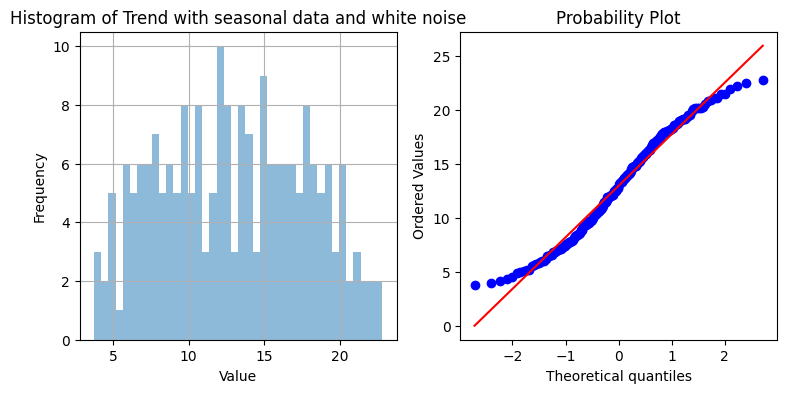

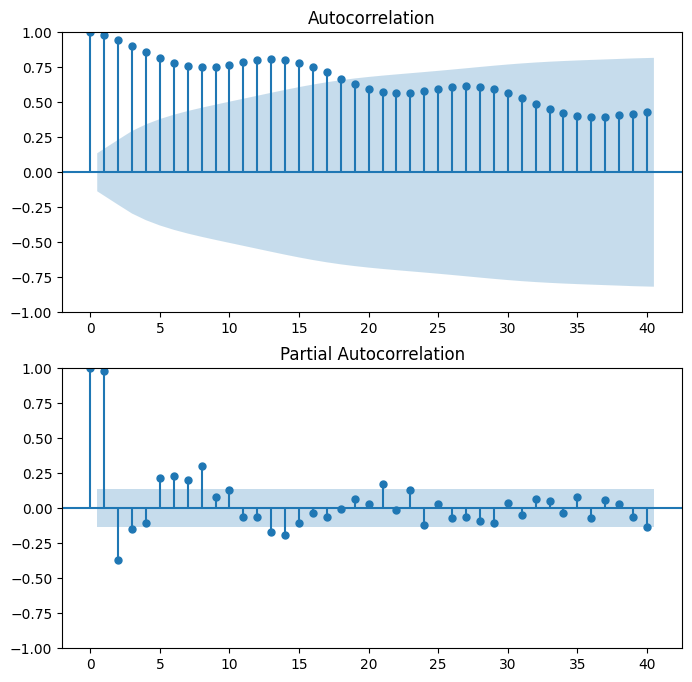

In [18]:
hist_qq_plots(ts, 'Trend with seasonal data and white noise')
acf_pacf_plots(ts)

# Decomposition of Time Series


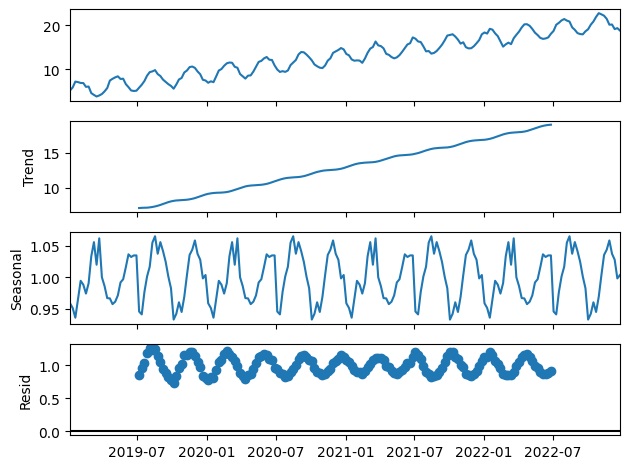

In [19]:
decomp = decomp_ts(ts, freq = 'W', model='model')

In [20]:
decomp.describe()

,resid,trend,seasonal
count,156.000000,156.000000,208.000000
mean,1.001889,12.958825,1.000000
std,0.126318,3.469367,0.037877
min,0.727475,7.119507,0.933196
25%,0.888518,10.066018,0.967145
50%,0.989616,12.886302,0.999398
75%,1.119721,15.777699,1.035016
max,1.269819,19.005953,1.065449


In [21]:
df = pd.DataFrame({'resid': decomp.resid, 
                   'trend': decomp.trend,
                   'seasonal': decomp.seasonal},
                  index = ts.index)
df.describe()

,resid,trend,seasonal
count,156.000000,156.000000,208.000000
mean,1.001889,12.958825,1.000000
std,0.126318,3.469367,0.037877
min,0.727475,7.119507,0.933196
25%,0.888518,10.066018,0.967145
50%,0.989616,12.886302,0.999398
75%,1.119721,15.777699,1.035016
max,1.269819,19.005953,1.065449


# Drop NA from trunkated observations

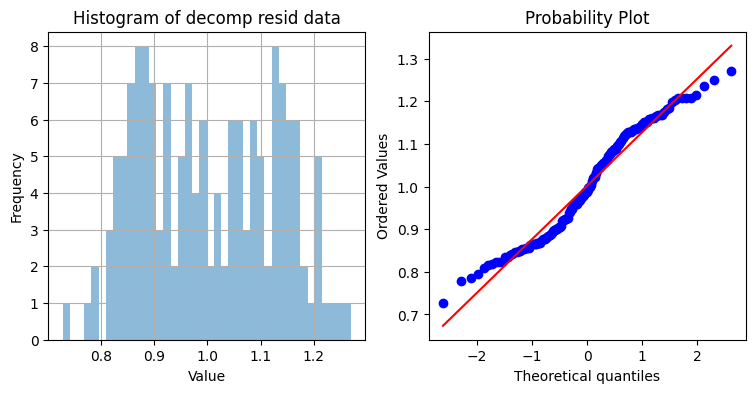

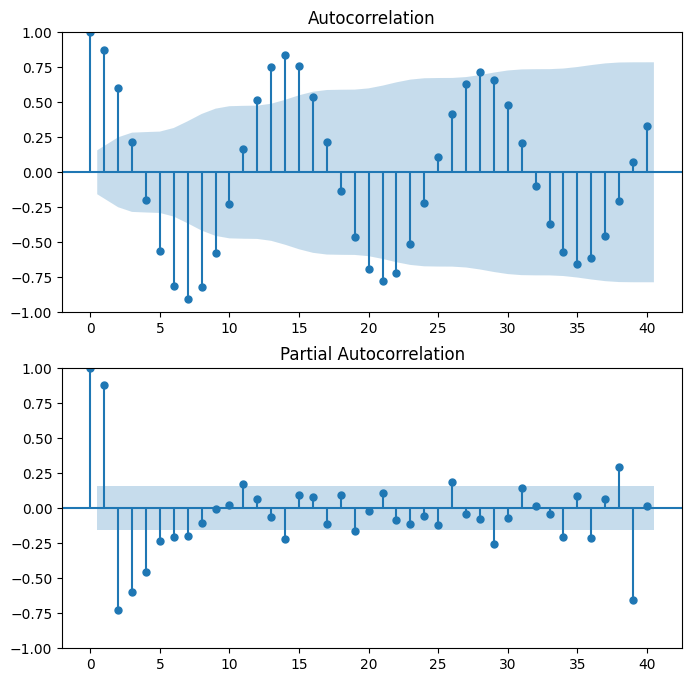

In [22]:
# Notice all those NaN values that will impact the plots. Dropna.
hist_qq_plots(decomp.resid.dropna(), 'decomp resid data')
acf_pacf_plots(decomp.resid.dropna())

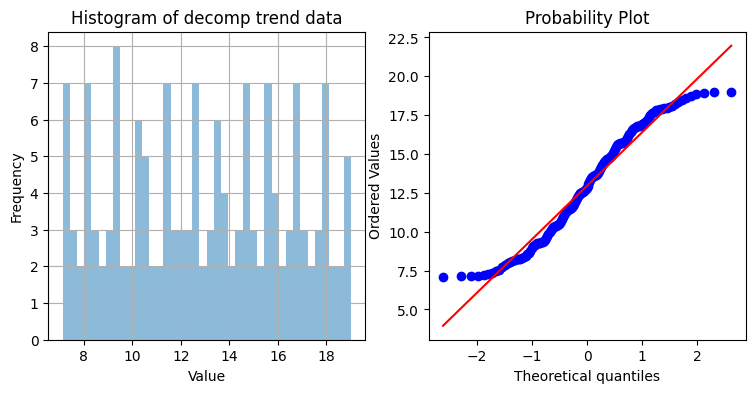

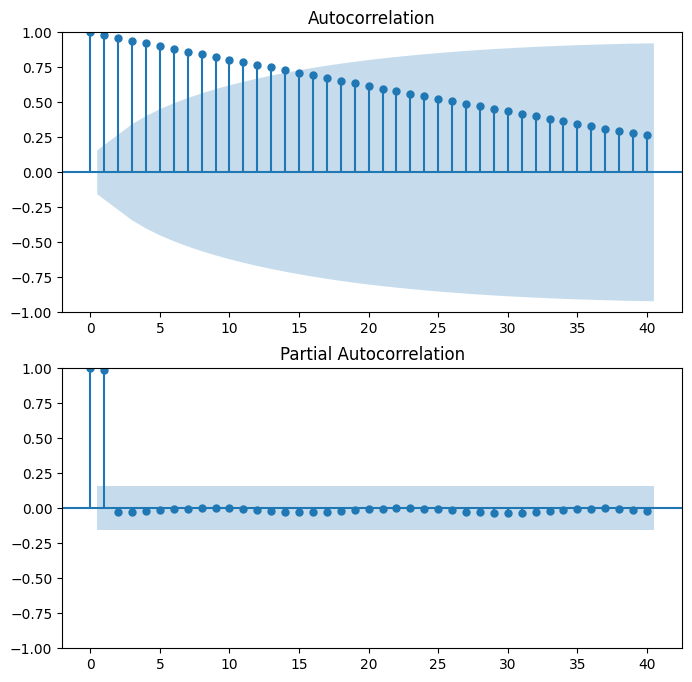

In [23]:
# Notice all those NaN values that will impact the plots. Dropna.
hist_qq_plots(decomp.trend.dropna(), 'decomp trend data')
acf_pacf_plots(decomp.trend.dropna())

# The SARIMAX Model

The order of the SARIMAX model is written, (p,d,q)(P,D,Q,M). The lower case (p,d,q) orders are the same as the, now familiar, ARIMA model for the residual. 

ARIMA (p, d, q) terms:
- **p** is the order of AR(p) series.
- **d** is an integrating term.
- **q** is the q white noise terms in MA(q) model.

The upper case (P,D,Q,M) are additional terms for SARIMAX:   
- **P** is the order of the **seasonal AR term**. This term defines the order of an autoregressive component with period **M**.  
- **D** is the order of differencing used to account for non-stationary behavior in the seasonal model. 
- **Q** is the order of the **seasonal MA term**. This term defines the order of a moving average component with period **M**. 

"The **P** and **Q** coefficients for seasonal AR and MA components are computed using a maximum likelihood estimator. Whereas, **D** and **M** are specified in advance. In addition SARIMAX typically uses a **polynomial trend model**." [Elston]

## Best model

In [24]:
best_model = pm.auto_arima(ts, start_p=1, start_q=1,
                             max_p=3, max_q=3, m=12,
                             start_P=0, seasonal=True,
                             d=1, D=1, trace=True,
                             information_criterion = 'bic',
                             error_action='ignore',  # don't want to know if an order does not work
                             suppress_warnings=True,  # don't want convergence warnings
                             stepwise=True)  # set to stepwise

Performing stepwise search to minimize bic
 ARIMA(1,1,1)(0,1,1)[12]             : BIC=inf, Time=0.31 sec
 ARIMA(0,1,0)(0,1,0)[12]             : BIC=442.041, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : BIC=440.782, Time=0.03 sec
 ARIMA(0,1,1)(0,1,1)[12]             : BIC=444.250, Time=0.07 sec
 ARIMA(1,1,0)(0,1,0)[12]             : BIC=435.768, Time=0.01 sec
 ARIMA(1,1,0)(0,1,1)[12]             : BIC=inf, Time=0.21 sec
 ARIMA(1,1,0)(1,1,1)[12]             : BIC=inf, Time=0.32 sec
 ARIMA(2,1,0)(0,1,0)[12]             : BIC=428.129, Time=0.01 sec
 ARIMA(2,1,0)(1,1,0)[12]             : BIC=431.972, Time=0.05 sec
 ARIMA(2,1,0)(0,1,1)[12]             : BIC=inf, Time=0.34 sec
 ARIMA(2,1,0)(1,1,1)[12]             : BIC=inf, Time=0.32 sec
 ARIMA(3,1,0)(0,1,0)[12]             : BIC=432.745, Time=0.02 sec
 ARIMA(2,1,1)(0,1,0)[12]             : BIC=433.215, Time=0.02 sec
 ARIMA(1,1,1)(0,1,0)[12]             : BIC=435.022, Time=0.02 sec
 ARIMA(3,1,1)(0,1,0)[12]             : BIC=436.075, T

In [25]:
best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  208
Model:             SARIMAX(2, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -206.155
Date:                            Wed, 01 Apr 2026   AIC                            418.310
Time:                                    13:03:05   BIC                            428.129
Sample:                                01-06-2019   HQIC                           422.286
                                     - 12-25-2022                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1800      0.075      2.415      0.016       0.034       0.326
ar.L2          0.2535      0.069      3.649      0.000       0.117       0.390
sigma2         0.4846      0.057      8.460      0.000       0.372       0.597
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 3.08
Prob(Q):                              0.85   Prob(JB):                         0.21
Heteroskedasticity (H):               0.94   Skew:                             0.18
Prob(H) (two-sided):                  0.80   Kurtosis:                         2.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Forecasting
The selected SARIMAX model can be used for prediction of time series values. Recall that the model parameters were estimated using all but the last 12 months of data. You will now make predictions from the model and compare the results to the known values.   

The code in the cell below performs prediction with the prediction method. A Pandas series is created from the results. Execute this code and examine the results.

In [26]:
# Predictions to compare results to actuals
prediction = pd.Series(best_model.predict(n_periods=10))
#, 
#                       index = pd.date_range(start = start, end = end, freq = 'W'))
prediction

2023-01-01    19.546685
2023-01-08    19.968983
2023-01-15    20.882245
2023-01-22    21.629249
2023-01-29    21.310085
2023-02-05    20.956844
2023-02-12    20.219995
2023-02-19    18.876003
2023-02-26    18.903076
2023-03-05    17.854935
Freq: W-SUN, dtype: float64

In [27]:
prediction.describe()

count    10.000000
mean     20.014810
std       1.219529
min      17.854935
25%      19.063979
50%      20.094489
75%      20.938194
max      21.629249
dtype: float64

# References

Material based on Harvard Data Modeling class conducted by Prof. Steven F. Elston. This topic is covered in chapter 34. Many examples are replicated and adapted here for educational and refernece purposes. 

1. Prof. Steven F. Elston. Harvard Data Modelling course: https://github.com/StephenElston/CSCI-E-83/blob/master/Notebooks/32_Chapter32_IntroToTimeSeries.ipynb Chapter 34.
1. Pandas: https://pandas.pydata.org/pandas-docs/stable/timeseries.html
1. ARIMA modeling tutorial from the 2011 Scipy: https://conference.scipy.org/scipy2011/slides/mckinney_time_series.pdf
1. SARIMAX tutorial in the Statsmodels documentation https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html
1. pmdarima package user quide: https://alkaline-ml.com/pmdarima/user_guide.html
1. "Forecasting, Principles and Practice", 2nd ed. by Rob J Hyndaman and George Athanaspoulos, available as an online book: (https://otexts.com/fpp2/ 
1. Darts: https://unit8co.github.io/darts/index.html, newly released Python time series package with deep learning models.  
1. Rob Hyndman's lecture notes: http://robjhyndman.com/uwafiles/5-Cross-validation.pdf). 
1. statsmodels.tsa.seasonal.seasonal_decompose: https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html).